In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
df.drop(columns=['RowNumber','Surname','CustomerId'],inplace=True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [13]:
X = df.drop(columns=['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split

x_train ,  x_test ,y_train , y_test = train_test_split(X,y,train_size=0.2,random_state=42)



In [14]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train_scale = scale.fit_transform(x_train)
x_test_scale = scale.transform (x_test)

In [15]:
x_train_scale

array([[-0.38381126,  2.60786056, -1.37934576, ..., -0.57427105,
        -0.58350885, -1.12244688],
       [-0.73723819,  0.12136034, -0.68041201, ...,  1.74133801,
        -0.58350885, -1.12244688],
       [ 0.32304261, -0.54808203, -0.33094513, ..., -0.57427105,
        -0.58350885,  0.89091075],
       ...,
       [ 0.85318301, -0.06990891, -1.37934576, ..., -0.57427105,
        -0.58350885, -1.12244688],
       [ 0.14632915,  0.40826421,  1.06692237, ..., -0.57427105,
        -0.58350885,  0.89091075],
       [ 0.45817644,  1.1733412 , -1.37934576, ...,  1.74133801,
        -0.58350885,  0.89091075]])

### Keras

In [16]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [17]:
model = Sequential()

model.add(Dense(5,activation = 'relu',input_dim=11))
model.add(Dense(5,activation = 'relu'))

model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-08-19 13:24:45.902299: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96 (384.00 B)

 Trainable params: 96 (384.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [20]:
history = model.fit(x_train_scale,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7962 - loss: 0.5490 - val_accuracy: 0.7900 - val_loss: 0.5513
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7962 - loss: 0.5190 - val_accuracy: 0.7900 - val_loss: 0.5320
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7962 - loss: 0.5000 - val_accuracy: 0.7900 - val_loss: 0.5188
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4878 - val_accuracy: 0.7900 - val_loss: 0.5092
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4790 - val_accuracy: 0.7900 - val_loss: 0.5019
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4723 - val_accuracy: 0.7900 - val_loss: 0.4953
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7962 - loss: 0.4669 - val_accuracy: 0.7900 - val_loss: 0.4887
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7962 - loss: 0.4625 - val_accuracy: 0.7900 - v

In [21]:
model.layers[0].get_weights()

[array([[ 0.2848904 , -0.27416778,  0.39780042,  0.09499253,  0.02670607],
        [-0.9179718 ,  0.17789769, -0.3289271 , -1.0770235 , -0.13212058],
        [-0.03571107,  0.21626294,  0.439341  ,  0.35324797,  0.1305256 ],
        [ 0.03010468,  0.00641605, -0.06253138,  0.02207544,  0.22650938],
        [ 0.32861897,  0.3395394 ,  0.96314734,  0.32533628,  0.9644075 ],
        [-0.03346792,  0.01226124,  0.6363986 , -0.32092884, -0.9476843 ],
        [-0.15511839,  0.6263267 , -0.2869643 ,  0.43193033,  0.01099291],
        [ 0.13497104, -0.44927186, -0.12555747,  0.44464228,  0.095917  ],
        [-0.16371745, -0.28582853,  0.31616333, -0.01725129, -0.11408073],
        [-0.8496542 ,  0.30850306,  0.2429681 ,  0.6182705 ,  0.24433815],
        [ 0.09352669,  0.13072637, -0.51236767, -0.09873901, -0.06353866]],
       dtype=float32),
 array([ 0.60709304,  0.4909013 , -0.04741418,  0.32545286, -0.17757124],
       dtype=float32)]

In [22]:
model.layers[1].get_weights()

[array([[ 6.3803393e-01, -8.7623233e-01,  9.7302604e-01, -8.0447364e-01,
          7.8904158e-01],
        [ 2.2490679e-01, -6.5191671e-02, -4.9058103e-04, -2.0633276e-01,
          8.9568198e-01],
        [-1.2782158e+00, -9.0113118e-02, -1.3689893e-01,  2.6718041e-01,
          7.5993188e-02],
        [-2.7281067e-01,  5.8598548e-01,  8.3216286e-01,  9.4831496e-01,
          4.2357409e-01],
        [ 6.3491988e-01,  7.6009673e-03, -1.3949826e-01, -6.5656751e-01,
         -1.3266900e+00]], dtype=float32),
 array([-0.02026204, -0.0023252 , -0.00040888, -0.15325911, -0.02093478],
       dtype=float32)]

In [23]:
model.predict(x_test_scale)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.09241191],
       [0.06749764],
       [0.3157603 ],
       ...,
       [0.13267078],
       [0.02068104],
       [0.17338921]], dtype=float32)

#### Now see the predicted value is an probability value between 0 & 1 , so you need to decide a threashold value and convert , this probability values into the output

In [24]:
y_log = model.predict(x_test_scale)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [25]:
import numpy as np
y_pred = np.where(y_log>0.5,1,0)

In [26]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

0.831875


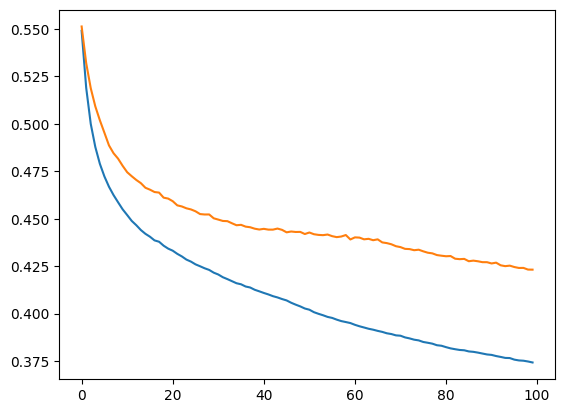

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

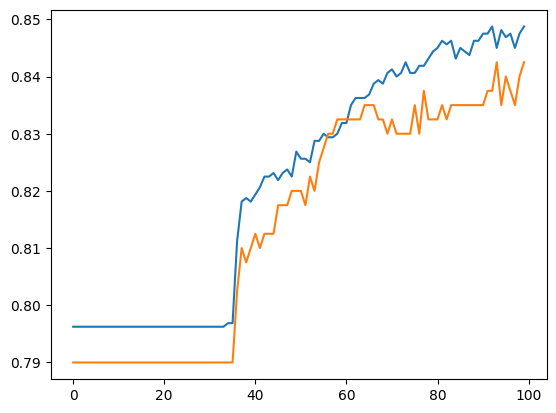

In [28]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])